In [1]:
# Cell 1 — Imports
import numpy as np
import matplotlib.pyplot as plt
import random
import json

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Cell 2 — Environment definition
class ThresholdEnv:
    def __init__(self, confidence_scores, true_labels):
        self.confidence_scores = confidence_scores
        self.true_labels = true_labels
        self.n_steps = len(confidence_scores)
        self.threshold_levels = np.linspace(0.1, 0.9, 9)
        self.current_step = 0
        self.current_threshold_idx = 4

    def reset(self):
        self.current_step = 0
        self.current_threshold_idx = 4
        return self.current_threshold_idx

    def step(self, action):
        if action == 0:
            self.current_threshold_idx = max(0, self.current_threshold_idx - 1)
        elif action == 2:
            self.current_threshold_idx = min(8, self.current_threshold_idx + 1)

        threshold = self.threshold_levels[self.current_threshold_idx]
        score = self.confidence_scores[self.current_step]
        true_label = self.true_labels[self.current_step]

        predicted_defect = score >= threshold
        actual_defect = true_label == 1

        if predicted_defect and actual_defect:
            reward = 1.0
        elif not predicted_defect and not actual_defect:
            reward = 0.5
        elif predicted_defect and not actual_defect:
            reward = -1.0
        else:
            reward = -2.0

        self.current_step += 1
        done = self.current_step >= self.n_steps
        return self.current_threshold_idx, reward, done

print("Environment defined.")
print("Actions: 0 = lower threshold, 1 = keep, 2 = raise threshold")
print("Reward: +1.0 true positive, +0.5 true negative, -1.0 false positive, -2.0 false negative")

Environment defined.
Actions: 0 = lower threshold, 1 = keep, 2 = raise threshold
Reward: +1.0 true positive, +0.5 true negative, -1.0 false positive, -2.0 false negative


In [3]:
# Cell 3 — Generate synthetic confidence scores
np.random.seed(SEED)
n_samples = 500

defect_scores = np.random.beta(7, 2, size=int(n_samples * 0.4))
normal_scores = np.random.beta(2, 7, size=int(n_samples * 0.6))

confidence_scores = np.concatenate([defect_scores, normal_scores])
true_labels = np.concatenate([
    np.ones(len(defect_scores)),
    np.zeros(len(normal_scores))
]).astype(int)

shuffle_idx = np.random.permutation(n_samples)
confidence_scores = confidence_scores[shuffle_idx]
true_labels = true_labels[shuffle_idx]

print(f"Total samples: {n_samples}")
print(f"Defect samples: {int(n_samples * 0.4)}")
print(f"Normal samples: {int(n_samples * 0.6)}")

Total samples: 500
Defect samples: 200
Normal samples: 300


In [4]:
# Cell 4 — Q-table and training
n_states = 9
n_actions = 3
Q = np.zeros((n_states, n_actions))

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05
n_episodes = 50

episode_rewards = []

env = ThresholdEnv(confidence_scores, true_labels)

for episode in range(n_episodes):
    state = env.reset()
    total_reward = 0
    done = False

    while not done:
        if random.random() < epsilon:
            action = random.randint(0, 2)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done = env.step(action)
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % 10 == 0:
        print(f"Episode {episode+1}/{n_episodes} | Total Reward: {total_reward:.2f} | Epsilon: {epsilon:.3f}")

Episode 10/50 | Total Reward: 147.50 | Epsilon: 0.951
Episode 20/50 | Total Reward: 173.00 | Epsilon: 0.905
Episode 30/50 | Total Reward: 162.50 | Epsilon: 0.860
Episode 40/50 | Total Reward: 212.00 | Epsilon: 0.818
Episode 50/50 | Total Reward: 233.00 | Epsilon: 0.778


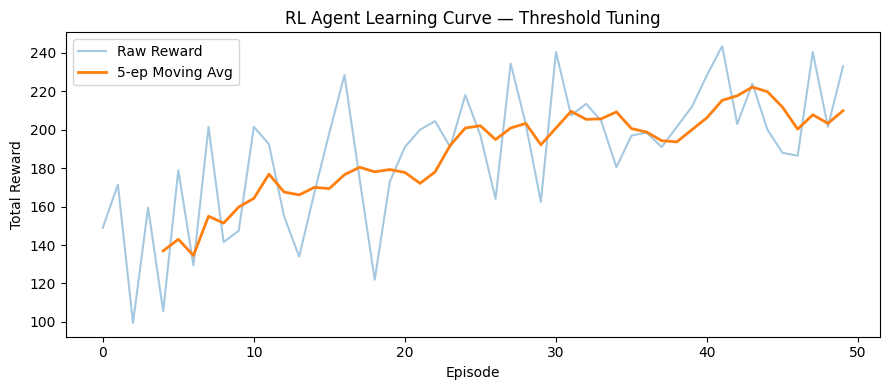

In [5]:
# Cell 5 — Learning curve
window = 5
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(9, 4))
plt.plot(episode_rewards, alpha=0.4, label="Raw Reward")
plt.plot(range(window - 1, len(episode_rewards)), smoothed, label=f"{window}-ep Moving Avg", linewidth=2)
plt.title("RL Agent Learning Curve — Threshold Tuning")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.tight_layout()
plt.savefig("rl_learning_curve.png", dpi=150)
plt.show()

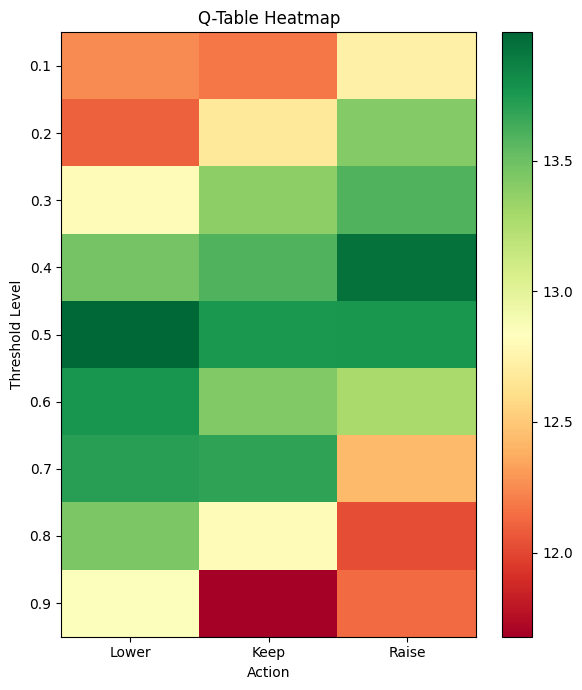

In [6]:
# Cell 6 — Q-table heatmap
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(Q, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Lower", "Keep", "Raise"])
ax.set_yticks(range(9))
ax.set_yticklabels([f"{t:.1f}" for t in np.linspace(0.1, 0.9, 9)])
ax.set_xlabel("Action")
ax.set_ylabel("Threshold Level")
ax.set_title("Q-Table Heatmap")
plt.tight_layout()
plt.savefig("rl_qtable_heatmap.png", dpi=150)
plt.show()

In [7]:
# Cell 7 — Save metrics
rl_metrics = {
    "episode_rewards": episode_rewards,
    "final_epsilon": round(epsilon, 4),
    "n_episodes": n_episodes,
    "alpha": alpha,
    "gamma": gamma,
    "n_states": n_states,
    "n_actions": n_actions,
    "seed": SEED
}

with open("rl_metrics.json", "w") as f:
    json.dump(rl_metrics, f, indent=2)

print(f"Final Q-table learned threshold preferences:")
for i, t in enumerate(np.linspace(0.1, 0.9, 9)):
    best_action = ["Lower", "Keep", "Raise"][np.argmax(Q[i])]
    print(f"  Threshold {t:.1f} → best action: {best_action}")

Final Q-table learned threshold preferences:
  Threshold 0.1 → best action: Raise
  Threshold 0.2 → best action: Raise
  Threshold 0.3 → best action: Raise
  Threshold 0.4 → best action: Raise
  Threshold 0.5 → best action: Lower
  Threshold 0.6 → best action: Lower
  Threshold 0.7 → best action: Lower
  Threshold 0.8 → best action: Lower
  Threshold 0.9 → best action: Lower


In [8]:
# Download outputs
from google.colab import files
files.download("rl_learning_curve.png")
files.download("rl_qtable_heatmap.png")
files.download("rl_metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>